# Main Notebook
### Fall Detection using CNN (Convolutional Neural Network) and MLP (Multilayer Perceptron) on the SisFall Dataset


Imports:

In [ ]:
%pip install \
    matplotlib==3.7.0 \
    numpy==1.23.5 \
    pandas==1.5.3 \
    scikit_learn==1.2.1 \
    seaborn==0.13.0 \
    tensorflow==2.12.0 \
    tqdm==4.64.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 22.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 99.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from tensorflow import keras
import tensorflow as tf

In [ ]:
import numpy as np
import pandas as pd

Data Loading:

In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/EPFL Masters 2025/EPFL ACAD/Master Semester 2/Digital_Epid_Project/Fall-Detection-System')

In [ ]:
from data_processor import *
from deep_models import *
from utils import *

In [ ]:
Result_Export_Path = '/content/drive/MyDrive/EPFL Masters 2025/EPFL ACAD/Master Semester 2/Digital_Epid_Project/Fall-Detection-System/Results'

In [ ]:
%%time

dataset_path = "/content/drive/MyDrive/EPFL Masters 2025/EPFL ACAD/Master Semester 2/Digital_Epid_Project/Fall-Detection-System/SisFall_dataset/"

import random
random.seed(42)

dp = DatasetProcessor()
print('1.Split Adresses...')
train, test = dp.get_file_name(dataset_path)
print('Length of train and test:',len(train), len(test))   # expect ~3500 and ~900

print('2.Extract Features and Labels...')
print('------------------------Train Dataset')
train_dataset = dp.datasets_to_nparray(train)
print('------------------------Test Dataset')
test_dataset = dp.datasets_to_nparray(test)

print('3.Windowing...')
print('------------------------Train Dataset')
X_train, y_train = dp.windowing3d(train_dataset)
print('------------------------Test Dataset')
X_test, y_test = dp.windowing3d(test_dataset)

print('4.Normalizing...')
scaler = StandardScaler()
X_train, X_test = dp.normalizer(scaler, X_train, X_test)

print('5.Calculate Class Weight...')
class_weight = dp.generate_class_weight(y_train)


1.Split Adresses...
Length of train and test: 3483 1022
2.Extract Features and Labels...
------------------------Train Dataset


100%|█████████| 3483/3483 [19:26<00:00,  2.99it/s]


------------------------Test Dataset


100%|█████████| 1022/1022 [05:50<00:00,  2.92it/s]


3.Windowing...
------------------------Train Dataset
------------------------Test Dataset
4.Normalizing...
5.Calculate Class Weight...
CPU times: user 56.3 s, sys: 3.34 s, total: 59.7 s
Wall time: 25min 22s


In [ ]:
# Save/Load the train and test set
save_data = False

prefix = "/content/drive/MyDrive/EPFL Masters 2025/EPFL ACAD/Master Semester 2/Digital_Epid_Project/Fall-Detection-System/Dataset/"

if save_data:
  save_pickle(X_train, prefix + 'X_train.pkl')
  save_pickle(y_train, prefix + 'y_train.pkl')
  save_pickle(X_test, prefix + 'X_test.pkl')
  save_pickle(y_test, prefix + 'y_test.pkl')

else:
  #X_train = load_pickle(prefix + 'X_train.pkl')
  y_train = load_pickle(prefix + 'y_train.pkl')
  X_test = load_pickle(prefix + 'X_test.pkl')
  y_test = load_pickle(prefix + 'y_test.pkl')
  data_processor = DatasetProcessor()
  class_weight = data_processor.generate_class_weight(y_train)

In [ ]:
#print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

y_train shape: (51150,)
X_test shape: (28137, 200, 9)
y_test shape: (28137,)


In [ ]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0, 1]), array([29557, 21593])),
 (array([0, 1]), array([22713,  5424])))

Start training CNN + MLP:

In [ ]:
import numpy as np

print('1. Build Model...')
train_evaluate_deep = Train_Evaluate_Deep()
cnn_model = train_evaluate_deep.build_cnn(input_size=X_train.shape[1:])

print('2. Train Model...')
cnn_history = train_evaluate_deep.train_deep_model(cnn_model,
                                                   X_train,
                                                   y_train,
                                                   optimizer=tf.optimizers.SGD(learning_rate=0.001),
                                                   loss_function=keras.losses.BinaryCrossentropy(),
                                                   callbacks=[get_early_stopping(metric='val_PRC', patience=10, mode='max')],
                                                   metrics=get_classifiaction_metrics(),
                                                   class_weight=class_weight,
                                                   epochs=50)



1. Build Model...
2. Train Model...
----------------------------------


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 200, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 200, 16)        │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 200, 32)        │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 200, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,652,545 (25.38 MB)

 Trainable params: 6,652,545 (25.38 MB)

 Non-trainable params: 0 (0.00 B)

None
----------------------------------
Epoch 1/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - AUC: 0.4970 - Accuracy: 0.5084 - FN: 1172.0000 - FP: 18943.0000 - PRC: 0.5526 - Precision: 0.5075 - Recall: 0.9434 - TN: 1285.0000 - TP: 19520.0000 - loss: 0.6964 - val_AUC: 0.5197 - val_Accuracy: 0.0881 - val_FN: 0.0000e+00 - val_FP: 9329.0000 - val_PRC: 0.1418 - val_Precision: 0.0881 - val_Recall: 1.0000 - val_TN: 0.0000e+00 - val_TP: 901.0000 - val_loss: 0.7667
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - AUC: 0.5003 - Accuracy: 0.5044 - FN: 240.0000 - FP: 20041.0000 - PRC: 0.5640 - Precision: 0.5051 - Recall: 0.9884 - TN: 187.0000 - TP: 20452.0000 - loss: 0.6917 - val_AUC: 0.5263 - val_Accuracy: 0.0881 - val_FN: 0.0000e+00 - val_FP: 9329.0000 - val_PRC: 0.1533 - val_Precision: 0.0881 - val_Recall: 1.0000 - val_TN: 0.0000e+00 - val_TP: 901.0000 - val_loss: 0.7747
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - AUC: 0.5122 - Accuracy: 0.5049 - FN: 154.0000 - FP: 20104.0000

3. Evaluation...
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

1) Plot ROC Curve...



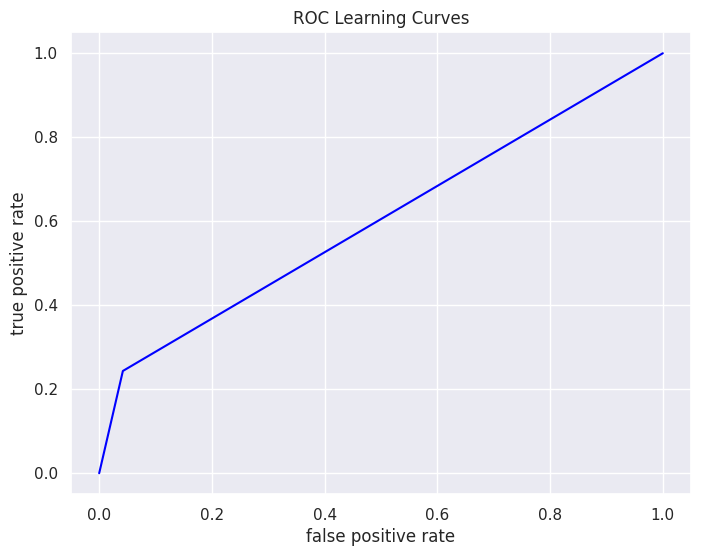


2) Plot AUC Curve...



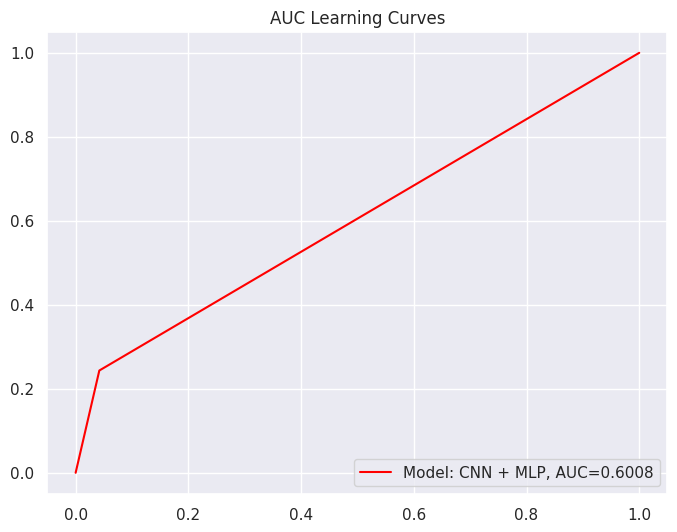


3) Plot Percision_Recall Curve......



<Figure size 800x600 with 0 Axes>

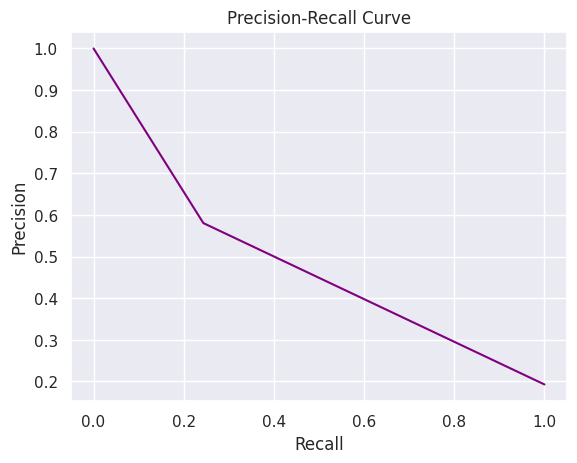

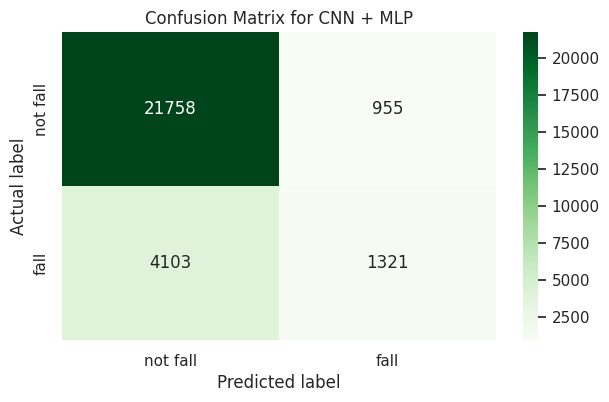


4. Plot learning curves...
1) Plot learning process based on different metrics...


2) Plot learning curve...



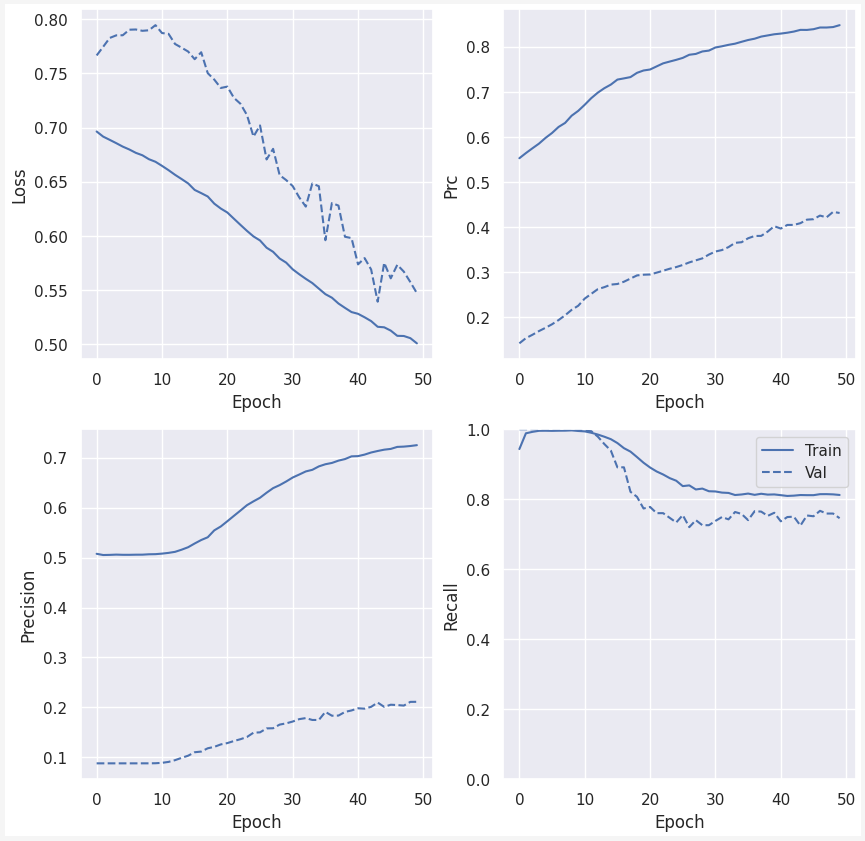

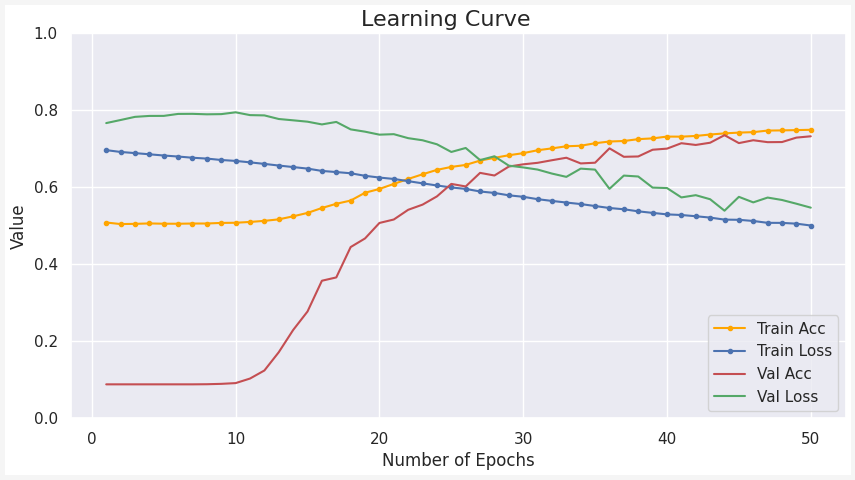

In [ ]:
print('3. Evaluation...')
prediction = train_evaluate_deep.evaluate(cnn_model, X_test, y_test, batch_size=128, threshold=0.9, title='CNN + MLP', model_name='CNN + MLP', plot=True)

plot_learning_curves=True
if plot_learning_curves:
  print('4. Plot learning curves...')
  _ = train_evaluate_deep.plot_learning_curves(cnn_history)

In [ ]:
convert_report_df(train_evaluate_deep.results)

,precision_0,recall_0,f1-score_0,support_0,precision_1,recall_1,f1-score_1,support_1,accuracy,precision_macro avg,recall_macro avg,f1-score_macro avg,support_macro avg,precision_weighted avg,recall_weighted avg,f1-score_weighted avg,support_weighted avg
CNN + MLP,0.841344,0.957954,0.895870,22713.000000,0.580404,0.243547,0.343117,5424.000000,0.820237,0.710874,0.600750,0.619494,28137.000000,0.791042,0.820237,0.789315,28137.000000


Saving model weights:

In [ ]:
import os
results_dir = '/content/drive/MyDrive/EPFL Masters 2025/EPFL ACAD/Master Semester 2/Digital_Epid_Project/Fall-Detection-System/Results'
os.makedirs(results_dir, exist_ok=True)

# Full model (architecture + weights + optimizer state) — recommended:
cnn_model.save(f'{results_dir}/cnn_mlp.keras')

Loading model:

In [ ]:
# Loading model:
from utils import load_pickle
from tensorflow import keras

results_dir = '/content/drive/MyDrive/EPFL Masters 2025/EPFL ACAD/Master Semester 2/Digital_Epid_Project/Fall-Detection-System/Results'


loaded_model = keras.models.load_model(f'{results_dir}/cnn_mlp.keras')
scaler = load_pickle(f'{results_dir}/scaler.pkl')

220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step



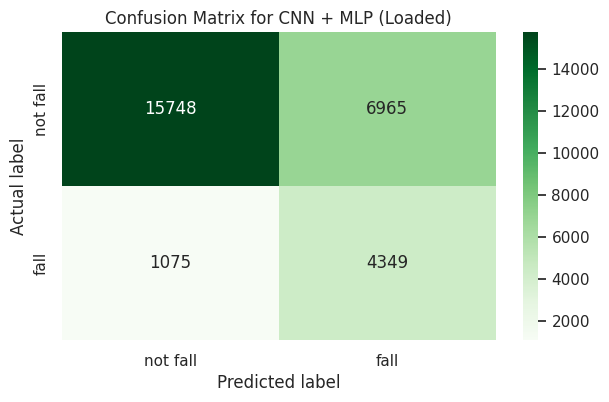

In [ ]:
prediction = train_evaluate_deep.evaluate(loaded_model, X_test, y_test, batch_size=128, threshold=0.5, title='CNN + MLP (Loaded)', model_name='CNN + MLP (Loaded)', plot=False)


In [ ]:
train_evaluate_deep.results['CNN + MLP (Loaded)']

{'0': {'precision': 0.936099387742971,
  'recall': 0.6933474221811298,
  'f1-score': 0.7966410360178066,
  'support': 22713.0},
 '1': {'precision': 0.3843910199752519,
  'recall': 0.8018067846607669,
  'f1-score': 0.5196558728641415,
  'support': 5424.0},
 'accuracy': 0.714255251092867,
 'macro avg': {'precision': 0.6602452038591115,
  'recall': 0.7475771034209484,
  'f1-score': 0.658148454440974,
  'support': 28137.0},
 'weighted avg': {'precision': 0.8297459674503985,
  'recall': 0.714255251092867,
  'f1-score': 0.7432463057713169,
  'support': 28137.0}}

In [ ]:
# Save training run and scaler preprocessing
from utils import save_pickle
save_pickle(cnn_history.history, f'{results_dir}/cnn_mlp_history.pkl')   # training curves
save_pickle(train_evaluate_deep.results, f'{results_dir}/cnn_mlp_results.pkl')  # eval report
save_pickle(scaler, f'{results_dir}/scaler.pkl')   # so future inputs can be normalized identically

Creating demo data:

In [ ]:
# save json of scaler data
import json
# scaler is your fitted StandardScaler
params = {
    "mean":  scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
    "var":   scaler.var_.tolist(),
    "n_features_in":   int(scaler.n_features_in_),
    "n_samples_seen":  int(scaler.n_samples_seen_),
}
with open("scaler.json", "w") as f:
    json.dump(params, f)

In [ ]:
import random
import pandas as pd
from build_sample_dataset import list_files, sample_windows

dataset_path = "/content/drive/MyDrive/EPFL Masters 2025/EPFL ACAD/Master Semester 2/Digital_Epid_Project/Fall-Detection-System/SisFall_dataset/"


rng = random.Random(42)
files = list_files(dataset_path)
fall_files = [e for e in files if e['is_fall']]
adl_files  = [e for e in files if not e['is_fall']]

fall_rows = sample_windows(fall_files, n=50, label=1, rng=rng,
                           center_on_middle=True, jitter=200)   # ±1 s
adl_rows  = sample_windows(adl_files,  n=50, label=0, rng=rng,
                           center_on_middle=False)

df = pd.DataFrame(fall_rows + adl_rows).sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,sensor,label,activity,subject,source_file,start_idx
0,"[[8.0, -98.0, 211.0, -21.0, 58.0, 14.0, -25.0,...",0,D11,SE08,/content/drive/MyDrive/EPFL Masters 2025/EPFL ...,1762
1,"[[-2.0, -269.0, -39.0, 6.0, 105.0, -16.0, -16....",0,D19,SA14,/content/drive/MyDrive/EPFL Masters 2025/EPFL ...,1895
2,"[[-260.0, -39.0, 6.0, 76.0, -183.0, -8.0, -100...",0,D14,SA14,/content/drive/MyDrive/EPFL Masters 2025/EPFL ...,1529
3,"[[-98.0, -68.0, 192.0, 0.0, 169.0, -15.0, -377...",1,F11,SA10,/content/drive/MyDrive/EPFL Masters 2025/EPFL ...,1107
4,"[[82.0, -237.0, -31.0, -1014.0, 454.0, 34.0, 2...",1,F07,SA05,/content/drive/MyDrive/EPFL Masters 2025/EPFL ...,1189


In [ ]:
# Indexes
non_fall = [0,12,21,27,32,14]
fall = [5,10,23,45,8,30]

In [ ]:
import os
import numpy as np

def save_samples(df_subset, out_dir='samples', fmt='%.6f'):
    """
    Save each row's (400, 9) sensor array to both .npy and .txt files.

    For each row, two files are created:
        {out_dir}/{activity}_{subject}.npy
        {out_dir}/{activity}_{subject}.txt

    If multiple rows share the same activity+subject (same trial sampled
    from different positions), an index suffix is appended.

    Args:
        df_subset: pd.DataFrame slice, e.g. df.iloc[[3, 7, 12, ...]]
                   must have columns 'sensor', 'activity', 'subject'
        out_dir:   output directory (created if missing)
        fmt:       np.savetxt format string for the .txt files

    Returns:
        list of (npy_path, txt_path) tuples written.
    """
    os.makedirs(out_dir, exist_ok=True)
    written, seen = [], {}
    for _, row in df_subset.iterrows():
        base = f"{row['activity']}_{row['subject']}"
        # disambiguate duplicates with _01, _02, ...
        seen[base] = seen.get(base, 0) + 1
        if seen[base] > 1:
            base = f"{base}_{seen[base]:02d}"

        arr = np.asarray(row['sensor'], dtype=np.float32)
        assert arr.shape == (400, 9), f"row {row.name}: expected (400, 9), got {arr.shape}"

        npy_path = os.path.join(out_dir, base + '.npy')
        txt_path = os.path.join(out_dir, base + '.txt')
        np.save(npy_path, arr)
        np.savetxt(txt_path, arr, fmt=fmt)
        written.append((npy_path, txt_path))

    print(f"Wrote {len(written)} npy + {len(written)} txt files to {out_dir}/")
    return written


In [ ]:
save_samples(df.iloc[non_fall])
save_samples(df.iloc[fall])

Wrote 6 npy + 6 txt files to samples/
Wrote 6 npy + 6 txt files to samples/


[('samples/F06_SE06.npy', 'samples/F06_SE06.txt'),
 ('samples/F12_SA21.npy', 'samples/F12_SA21.txt'),
 ('samples/F06_SA13.npy', 'samples/F06_SA13.txt'),
 ('samples/F02_SA20.npy', 'samples/F02_SA20.txt'),
 ('samples/F06_SA07.npy', 'samples/F06_SA07.txt'),
 ('samples/F07_SA17.npy', 'samples/F07_SA17.txt')]

In [ ]:
activity_map = {
    # Falls (F01–F15)
    "F01": "FALL: Fall forward while walking caused by a slip",
    "F02": "FALL: Fall backward while walking caused by a slip",
    "F03": "FALL: Lateral fall while walking caused by a slip",
    "F04": "FALL: Fall forward while walking caused by a trip",
    "F05": "FALL: Fall forward while jogging caused by a trip",
    "F06": "FALL: Vertical fall while walking caused by fainting",
    "F07": "FALL: Fall while walking, with use of hands on a table to dampen fall, caused by fainting",
    "F08": "FALL: Fall forward when trying to get up",
    "F09": "FALL: Lateral fall when trying to get up",
    "F10": "FALL: Fall forward when trying to sit down",
    "F11": "FALL: Fall backward when trying to sit down",
    "F12": "FALL: Lateral fall when trying to sit down",
    "F13": "FALL: Fall forward while sitting, caused by fainting or falling asleep",
    "F14": "FALL: Fall backward while sitting, caused by fainting or falling asleep",
    "F15": "FALL: Lateral fall while sitting, caused by fainting or falling asleep",

    # Activities / ADLs (D01–D19)
    "D01": "ACTIVITY: Walking slowly",
    "D02": "ACTIVITY: Walking quickly",
    "D03": "ACTIVITY: Jogging slowly",
    "D04": "ACTIVITY: Jogging quickly",
    "D05": "ACTIVITY: Walking upstairs and downstairs slowly",
    "D06": "ACTIVITY: Walking upstairs and downstairs quickly",
    "D07": "ACTIVITY: Slowly sit in a half height chair, wait a moment, and up slowly",
    "D08": "ACTIVITY: Quickly sit in a half height chair, wait a moment, and up quickly",
    "D09": "ACTIVITY: Slowly sit in a low height chair, wait a moment, and up slowly",
    "D10": "ACTIVITY: Quickly sit in a low height chair, wait a moment, and up quickly",
    "D11": "ACTIVITY: Sitting a moment, trying to get up, and collapse into a chair",
    "D12": "ACTIVITY: Sitting a moment, lying slowly, wait a moment, and sit again",
    "D13": "ACTIVITY: Sitting a moment, lying quickly, wait a moment, and sit again",
    "D14": "ACTIVITY: Being on one's back change to lateral position, wait a moment, and change to one's back",
    "D15": "ACTIVITY: Standing, slowly bending at knees, and getting up",
    "D16": "ACTIVITY: Standing, slowly bending without bending knees, and getting up",
    "D17": "ACTIVITY: Standing, get into a car, remain seated and get out of the car",
    "D18": "ACTIVITY: Stumble while walking",
    "D19": "ACTIVITY: Gently jump without falling (trying to reach a high object)"
}

Plot fall and non-fall data:

In [ ]:
def plot(npy_file):

    arr = np.load(npy_file)

    columns = [
        'ADXL345_x', 'ADXL345_y', 'ADXL345_z',
        'ITG3200_x', 'ITG3200_y', 'ITG3200_z',
        'MMA8451Q_x', 'MMA8451Q_y', 'MMA8451Q_z'
    ]

    # Legend label mapping
    label_map = {
        'ADXL345_x': 'Acceleration1_x',
        'ADXL345_y': 'Acceleration1_y',
        'ADXL345_z': 'Acceleration1_z',

        'ITG3200_x': 'Rotation_x',
        'ITG3200_y': 'Rotation_y',
        'ITG3200_z': 'Rotation_z',

        'MMA8451Q_x': 'Acceleration2_x',
        'MMA8451Q_y': 'Acceleration2_y',
        'MMA8451Q_z': 'Acceleration2_z'
    }

    # 400 samples = 2 sec = 2000 ms
    time_ms = np.linspace(0, 2000, arr.shape[0])

    # Extract first 3 letters from filename
    prefix = os.path.basename(npy_file)[:3]
    subtitle = activity_map.get(prefix, 'Unknown Activity')

    # Colors
    colors = {
        'ADXL345_x': '#2ca02c',
        'ITG3200_x': '#66c266',
        'MMA8451Q_x': '#006400',

        'ADXL345_y': '#d62728',
        'ITG3200_y': '#ff6b6b',
        'MMA8451Q_y': '#8b0000',

        'ADXL345_z': '#1f77b4',
        'ITG3200_z': '#6baed6',
        'MMA8451Q_z': '#003f88'
    }

    plt.figure(figsize=(16, 8))

    for i, col in enumerate(columns):
        plt.plot(
            time_ms,
            arr[:, i],
            label=label_map[col],
            color=colors[col],
            linewidth=2
        )

    # Title + subtitle
    plt.suptitle('Sensor Measurements (2 seconds)', fontsize=16, y=0.98)
    plt.title(subtitle, fontsize=12, color='dimgray')

    plt.xlabel('Milliseconds (ms)', fontsize=13)
    plt.ylabel('Sensor Value', fontsize=13)

    # X-axis ticks in milliseconds
    plt.xticks(np.arange(0, 2001, 250))

    plt.grid(True, alpha=0.3)

    plt.legend(
        loc='upper right',
        fontsize=10,
        ncol=3,
        frameon=True
    )

    plt.tight_layout()
    plt.show()

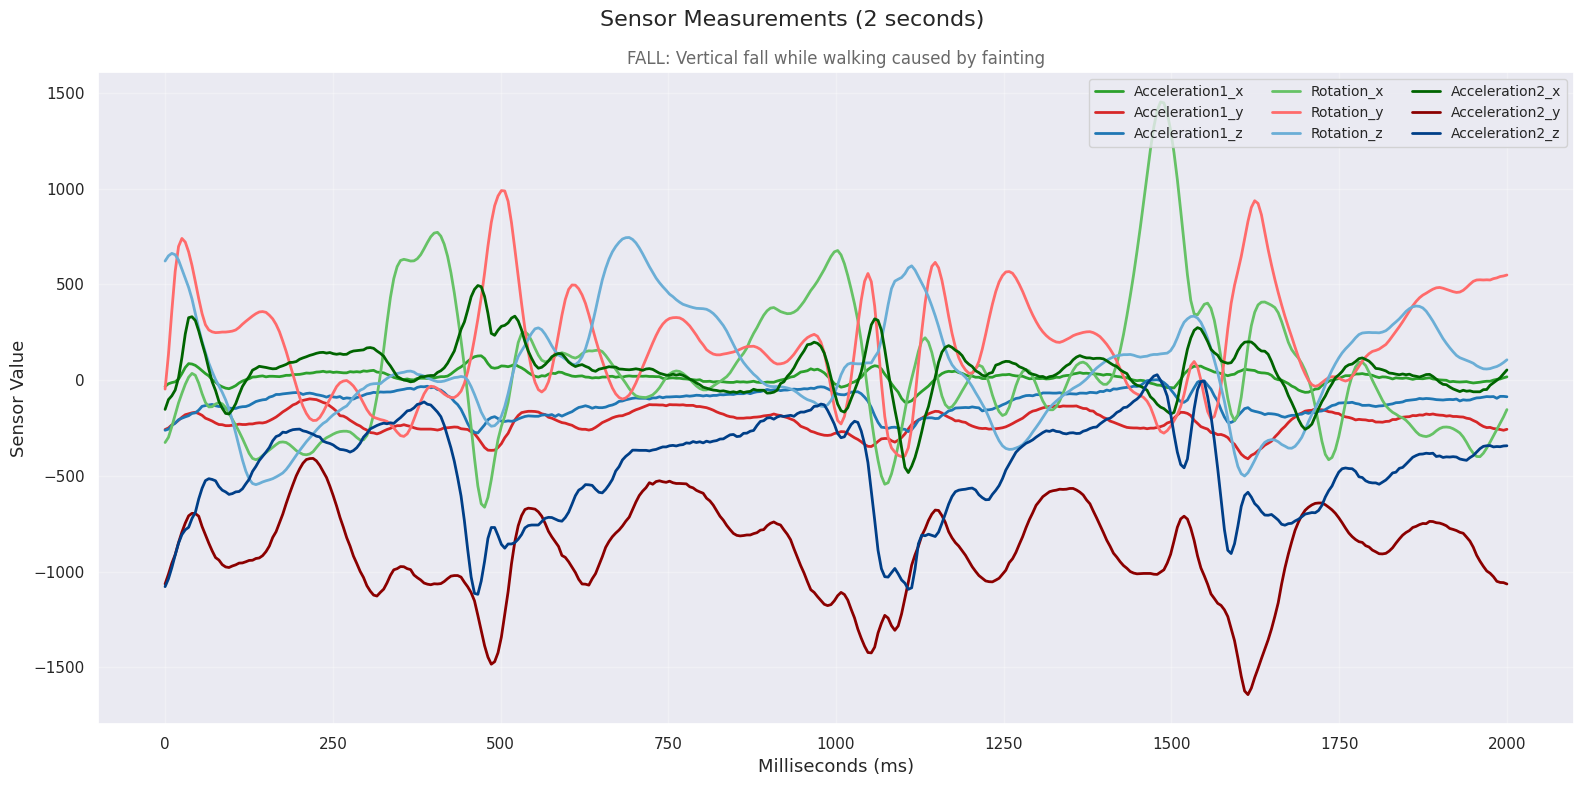

In [ ]:
plot("/content/samples/F06_SE06.npy")

In [ ]:
def run_model(rows):
    """Return (fall_detected, confidence).

    - fall_detected: int, 0 or 1
    - confidence:    float in 0.0..1.0  (the dashboard will format as %)
    """

    sample = np.asarray(rows, dtype=np.float32)
    assert sample.shape == (200, 9), f"expected (200, 9), got {sample.shape}"

    threshold = 0.5

    prob = float(loaded_model.predict(np.expand_dims(sample, axis=0))[0][0])
    label = int(prob >= threshold)
    return label, prob * 100